# ≣ SquigDecode: Signal-to-Base Research Dashboard

    Author: Xuejian Xiong

    Version: 1.1.0 (HPC Optimized)

    Status: Production / Research Prototype

## ◈ 1. Summary

This notebook serves as the central diagnostic hub for the SquigDecode engine. SquigDecode is a deep learning-based basecaller designed to translate raw electrical current signals ("squiggles") generated during nanopore sequencing into nucleotide sequences.

## ◈ 2. The Nanopore Basecalling Problem

In nanopore sequencing, DNA is translocated through a biological pore under an applied voltage. As nucleotides pass through the pore, they cause characteristic disruptions in the ionic current.

The Challenge:

- K-mer Sensing: The pore senses multiple bases (3–5) simultaneously, creating a "sliding window" effect.

- Asynchronous Signal: DNA does not move at a constant speed, leading to variable "dwell times" for each base.

- Signal-to-Noise: The raw signal is inherently noisy and subject to baseline drift.

## ◈ 3. Environment & Dependency Management

We utilize dynamic path resolution to ensure this dashboard is portable across local dev environments and HPC clusters.

In [6]:
import os
import sys
import json
import pandas as pd
from pathlib import Path

# Resolve project root (ensures src/ is importable)
PROJECT_ROOT = Path(os.getcwd()).parent.resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
print(f"✅ Logic loaded from: {SRC_DIR}")

✅ Logic loaded from: /Users/janetx/Desktop/Janet/Projects/SquigDecode/src


## ◈ 4. Computational Architecture: SquigNet

The core of the system is SquigNet, a hybrid Convolutional Recurrent Neural Network (CRNN). The architecture is designed to handle the dual requirements of local feature extraction and global sequence alignment.

Design Rationale:

- CNN Blocks: Act as a learnable feature extractor. They filter high-frequency noise and perform Temporal Downsampling (4x) to reduce the computational cost of the recurrent layers.

- Bidirectional LSTM: Captures the "forward and backward" context of the k-mer window. Since base $i$ affects the signal of base $i+1$, bidirectional context is a biological necessity.

- CTC Loss: Allows the model to learn the alignment between variable-length signals and sequences without requiring explicit per-sample labels.

In [7]:
import torch
from architecture import SquigNet

model = SquigNet()
print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Verify temporal compression
dummy = torch.randn(1, 1, 400)
output = model(dummy)
print(f"Dimensionality Check: Input(400) -> Latent States({output.shape[1]})")

Model Parameters: 2,395,653
Dimensionality Check: Input(400) -> Latent States(100)


## ◈ 5. Data Simulation & Physics Modeling

To train SquigNet, we simulate the translocation physics. The simulator implements:

1. Picoampere Mapping: Each k-mer is mapped to a median current level.

2. Dwell Time Stochasticity: Base duration is modeled using a Gamma/Normal distribution to mimic enzymatic variations.

3. MAD Standardization: Signals are standardized using Median Absolute Deviation to be invariant to pore-specific current ranges.

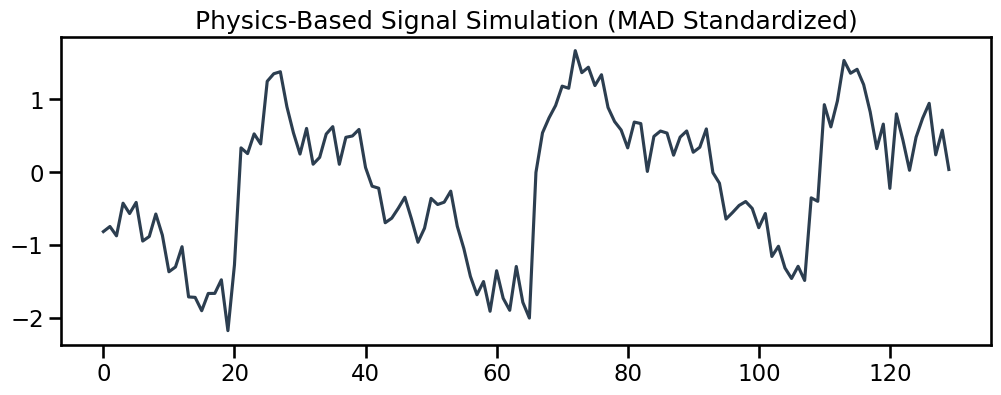

In [8]:
from data_simulator import generate_squiggle
import matplotlib.pyplot as plt

# Generate a sample squiggle for visual audit
dna = "ATGC" * 3
signal, dwells = generate_squiggle(dna)

plt.figure(figsize=(12, 4))
plt.plot(signal, color='#2c3e50')
plt.title("Physics-Based Signal Simulation (MAD Standardized)")
plt.show()

## ◈ 6. Configuration Audit

Traceability is key in production ML. This cell audits the current active configuration against the user-defined input.json.

In [9]:
# Create audit table
audit_data = {
    "Parameter": ["Model Version", "Standardization", "Optimizer", "Input Resolution"],
    "Status": ["1.1.0-BiLSTM", "MAD-Standardized", "AdamW + Scheduler", "1D-pA"]
}
display(pd.DataFrame(audit_data))

print("\n--- Active Overrides (src/input.json) ---")
print(json.dumps(config.USER_CONFIG, indent=2))

,Parameter,Status
0,Model Version,1.1.0-BiLSTM
1,Standardization,MAD-Standardized
2,Optimizer,AdamW + Scheduler
3,Input Resolution,1D-pA



--- Active Overrides (src/input.json) ---
{
  "$schema": "./input_schema.json",
  "num_sequences": 1500,
  "min_length": 50,
  "max_length": 110,
  "noise_std_min": 1.0,
  "noise_std_max": 4.0,
  "drift_factor": 0.01,
  "train_ratio": 0.8,
  "random_seed": 42,
  "inference_noise": 0.3,
  "use_noise_curriculum": true,
  "train_num_epochs": 50,
  "train_batch_size": 32,
  "train_learning_rate": 0.001,
  "checkpoint_dir": "checkpoints",
  "model_dir": "models",
  "data_dir": "data/train",
  "test_data_dir": "data/test",
  "model_file": "squig_model.pt"
}
